
=== Bootstrap 1/10 ===

Chosen filter -> Eg_strong/Eg_weak >= 1.21, data_quantity >= 25 | CV acc=0.9426, CV bin acc=0.9723, n_rows(dedup)=505
OOB cameras: ['kenttarova', 'oregon_yp', 'queens', 'torgnon', 'underc', 'varrio', 'wslcreek']
OOB n=345 | RMSE=0.0987 | Bias=0.0314 | FracRMSE=0.1619 | FracBias=-0.0566
10.92s

=== Bootstrap 2/10 ===

Chosen filter -> Eg_strong/Eg_weak >= 1.28, data_quantity >= 22 | CV acc=0.9491, CV bin acc=0.9915, n_rows(dedup)=589
OOB cameras: ['bartlett', 'lacclair', 'old_jack_pine', 'sodankyla_full', 'torgnon', 'willowcreek']
OOB n=301 | RMSE=0.1810 | Bias=-0.0026 | FracRMSE=0.4006 | FracBias=-0.1631
11.32s

=== Bootstrap 3/10 ===

Chosen filter -> Eg_strong/Eg_weak >= 1.15, data_quantity >= 28 | CV acc=0.9209, CV bin acc=0.9581, n_rows(dedup)=430
OOB cameras: ['bartlett', 'kenttarova', 'marcell_MN', 'oregon_yp', 'sodankyla_full', 'torgnon', 'varrio']
OOB n=373 | RMSE=0.1184 | Bias=0.0181 | FracRMSE=0.2826 | FracBias=-0.1515
10.2s

=== Bootstrap 4/10 ===

C

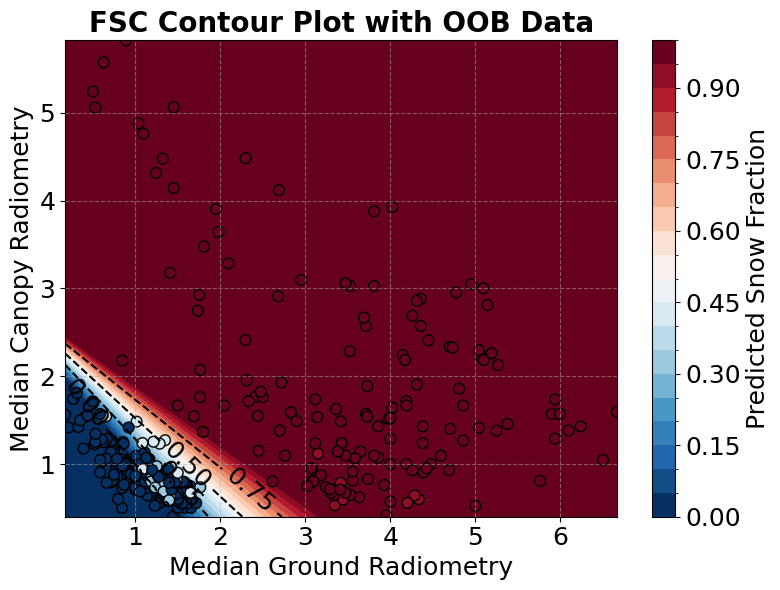

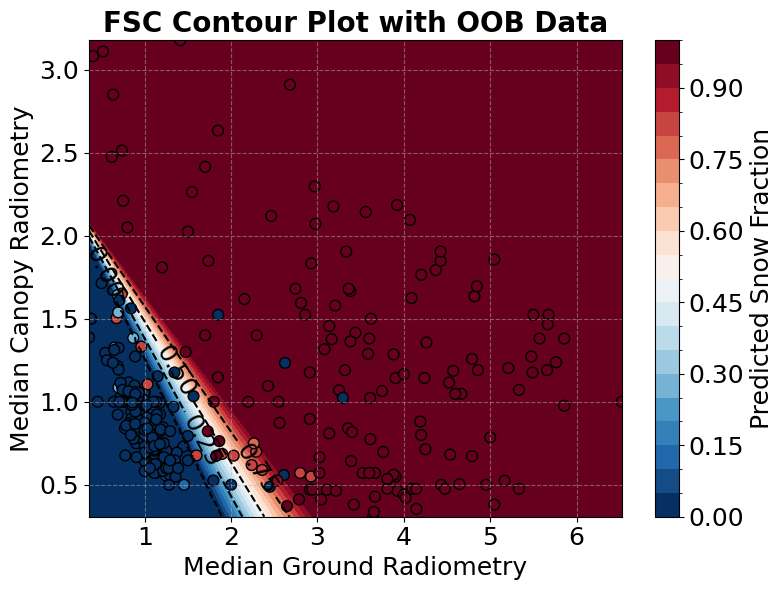

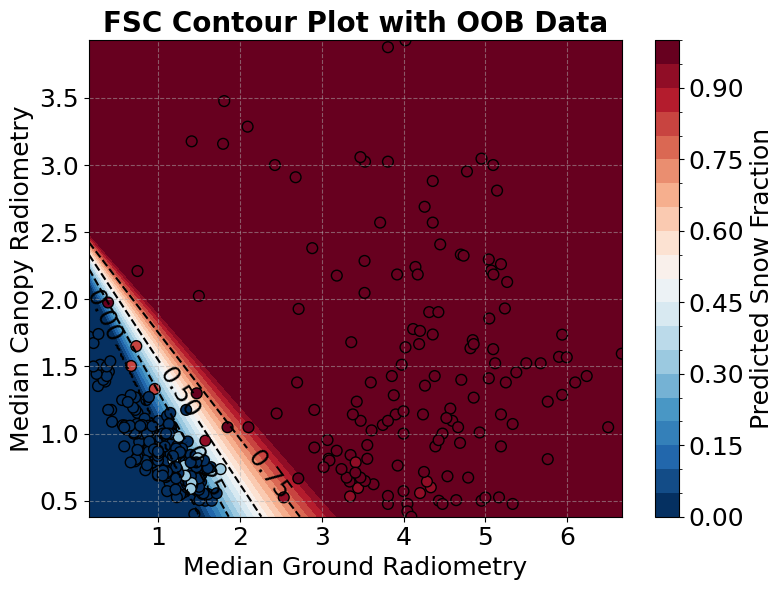

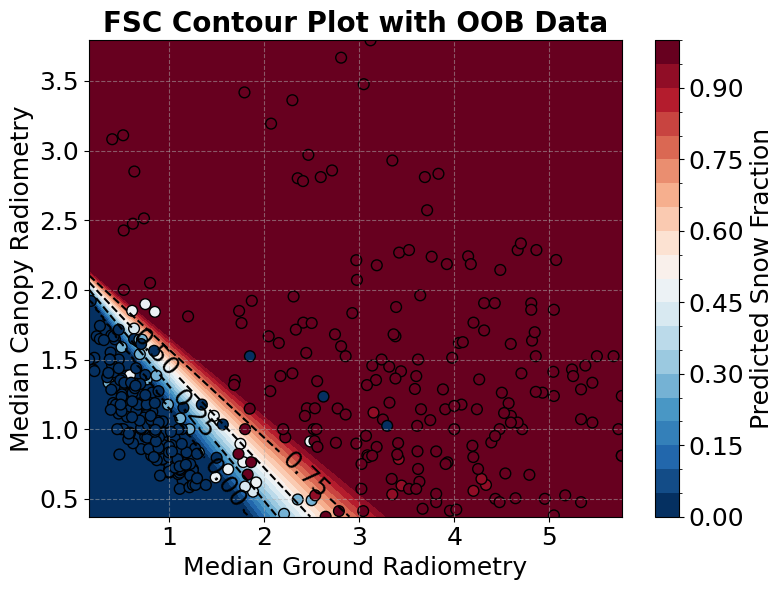

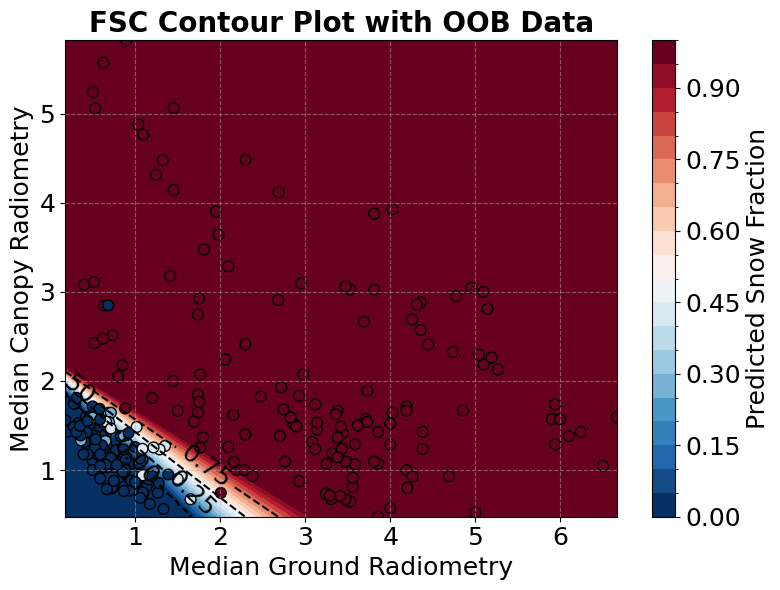

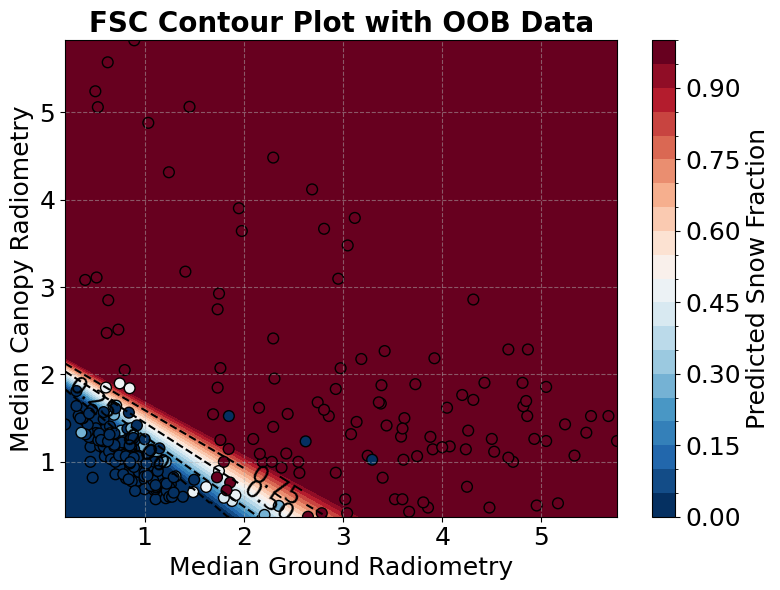

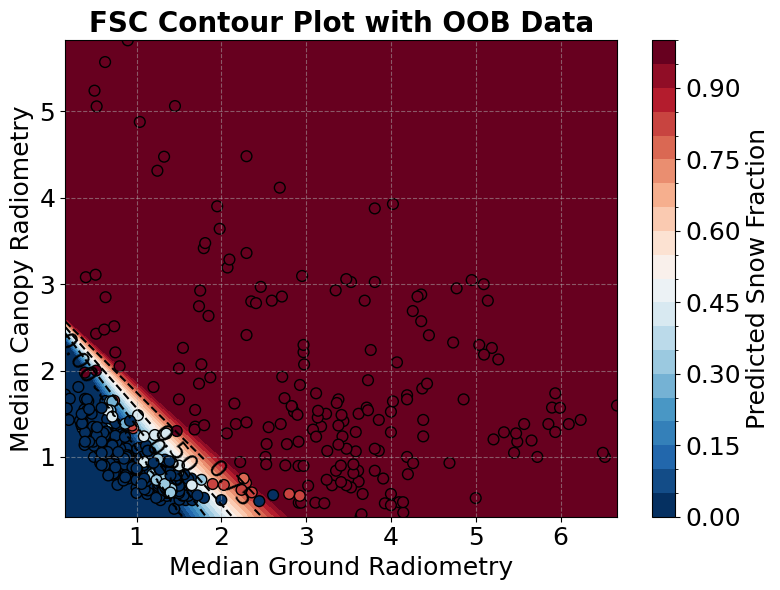

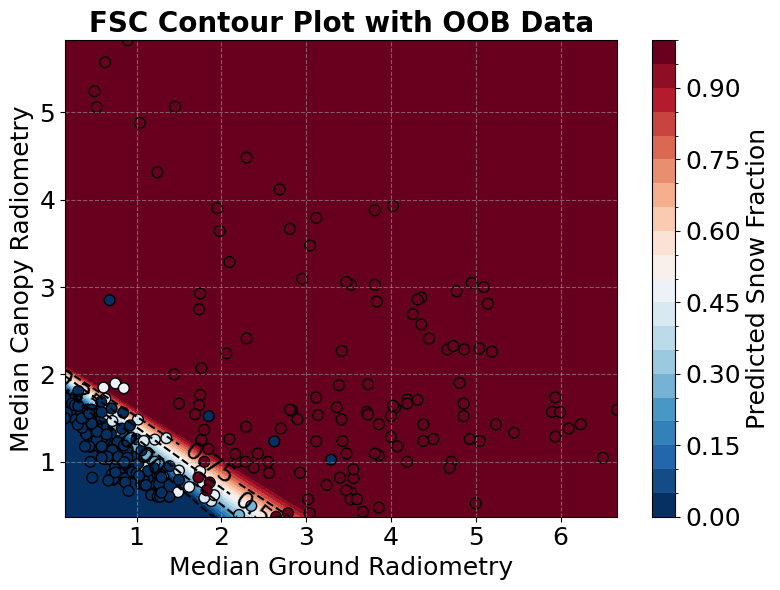

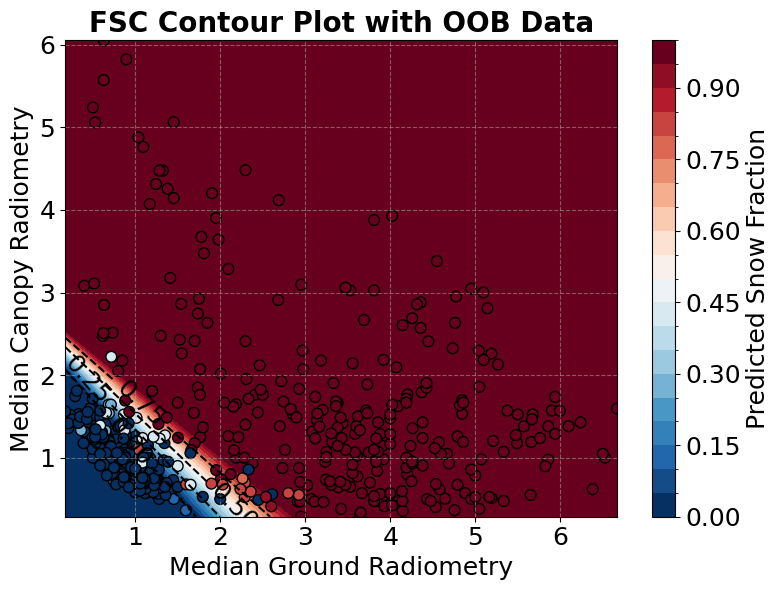

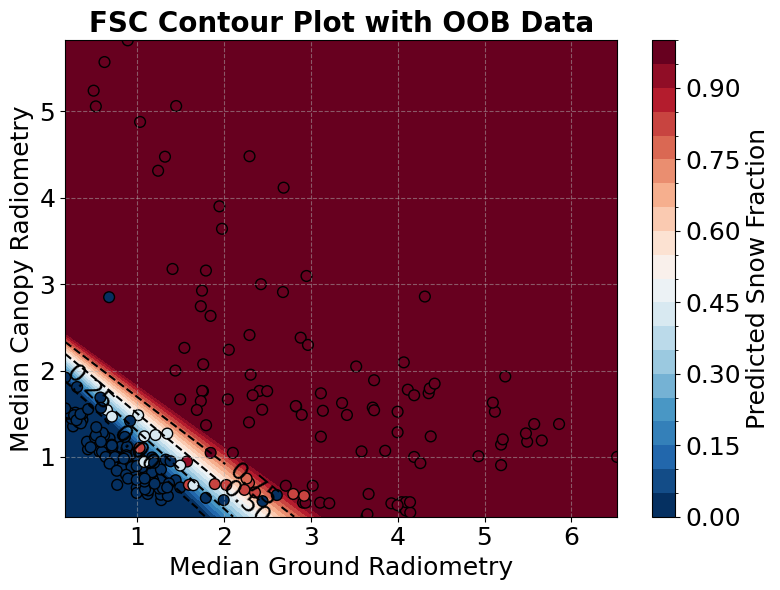

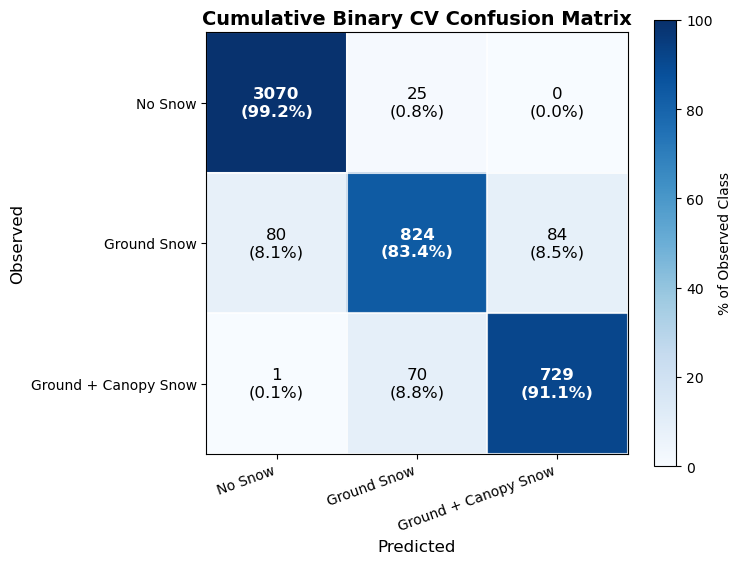

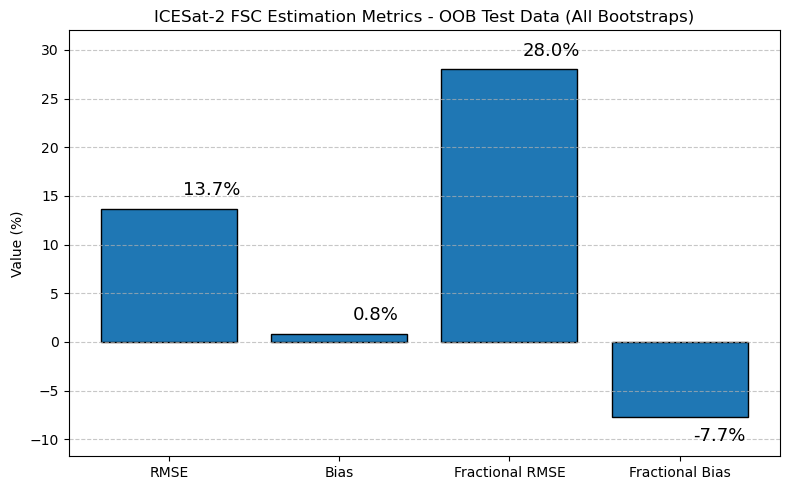

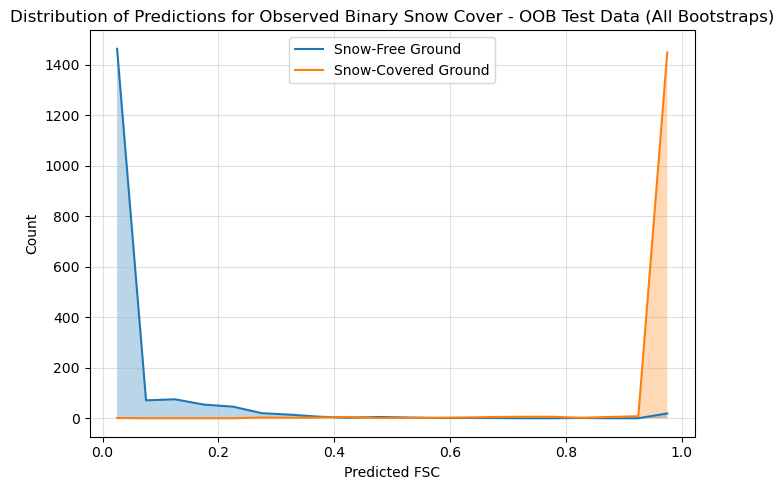

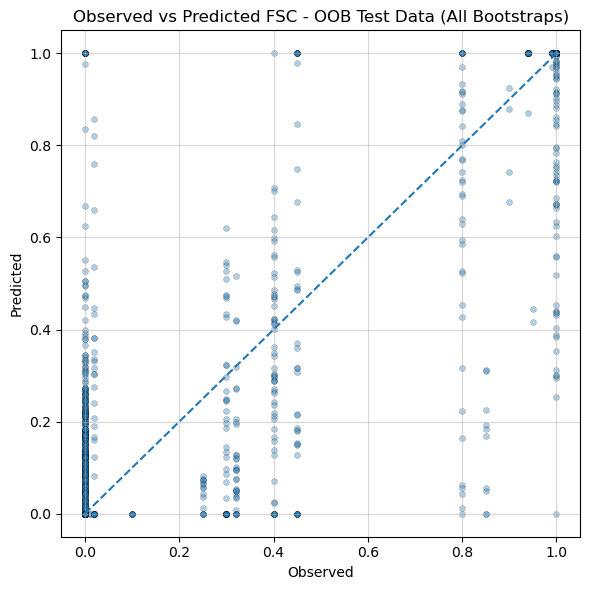

In [2]:
from scripts.imports import *
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from textwrap import fill

df = pd.read_pickle(
    'dataset_lcforest_noLOF_bin15_th3_80m_1kmsmallbox_noprior_ta_wc1_v7.pkl'
)

df['Eg_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Eg'], np.nan
)
df['Ev_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Ev'], np.nan
)
df['Eg_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Eg'], np.nan
)
df['Ev_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Ev'], np.nan
)
df['forest_type'] = np.where(
    df['segment_landcover'] < 119, 'closed', 'open'
)

df_grouped = df.groupby(['camera', 'date', 'lat', 'lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'median',
    'Ev_strong': 'median',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'FSC': 'mean',
    'TreeSnow': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()

df_grouped = df_grouped[df_grouped['Eg_strong'] >= 0]
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']


# ===========================================================
# PHASE 2: Bootstrap -> optimize filters on DEDUP -> train
#          angular model on DUPLICATED boot set
#          -> predict on OOB cameras
# ===========================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, mean_squared_error
from scipy.optimize import minimize


# ------------------------------ config ------------------------------
EG_COL = "Eg_strong"
EV_COL = "Ev_strong"
Y_BIN_COL = "JointSnowBinary"

FRAC_W = 1.0
N_BOOT = 10
N_SPLITS_CV = 5

RATIO_GRID = np.round(np.arange(1.05, 1.30 + 1e-9, 0.01), 2)
DQ_GRID = np.arange(12, 36)

TOL_NEAR = 0.003
RNG = np.random.RandomState(42)


# ------------------------------ base conditions ------------------------------
def base_conditions_opt(df):
    return (
        ((df['FSC'] <= 0.005) | (df['FSC'] >= 0.995)) &
        ((df['TreeSnow'] == 0) | (df['TreeSnow'] == 1)) &
        (df['Eg_strong'] >= 0)
    )


def base_conditions_boot(df):
    return (
        (df['FSC'] >= 0.0) &
        (df['FSC'] <= 1.0) &
        (df['Eg_strong'] >= 0)
    )


def apply_filters_for_search(df, ratio_thresh, dq_thresh):
    cond = (
        base_conditions_opt(df) &
        ((df['Eg_strong'] / df['Eg_weak']) >= ratio_thresh) &
        (df['data_quantity'] >= dq_thresh)
    )

    out = df.loc[cond].copy()
    out['JointSnow'] = out['FSC'] + out['TreeSnow']
    out['JointSnowRounded'] = np.round(out['JointSnow']).astype(int)

    return out


def apply_filters_for_boot(df, ratio_thresh, dq_thresh):
    cond = (
        base_conditions_boot(df) &
        ((df['Eg_strong'] / df['Eg_weak']) >= ratio_thresh) &
        (df['data_quantity'] >= dq_thresh)
    )

    out = df.loc[cond].copy()
    out['JointSnow'] = out['FSC'] + out['TreeSnow']

    # Cap ground + canopy snow at 1 for the angular model.
    out['JointSnowBinary'] = out['JointSnow'].apply(
        lambda x: 1 if x >= 1 else x
    ).astype(float)

    return out


# ------------------------------ CV metrics for filter search ------------------------------
def assign_folds_by_camera(df, n_splits=5):
    """
    Round-robin assignment by camera frequency.
    Returns fold indices aligned to dataframe rows.
    """
    counts = df['camera'].value_counts()
    cams_sorted = counts.index.tolist()

    cam2fold = {
        cam: (i % n_splits)
        for i, cam in enumerate(cams_sorted)
    }

    return df['camera'].map(cam2fold).to_numpy()


def cv_multinomial_metrics(
    df,
    features=('Eg_strong', 'Ev_strong'),
    n_splits=5
):
    """
    Camera-grouped CV for the three-class target (0, 1, 2).

    Returns:
        Multiclass accuracy.
        Aggregated 3x3 confusion matrix.
        Binary accuracy after collapsing classes 1 and 2.
    """
    if df.shape[0] == 0 or df['JointSnowRounded'].nunique() < 2:
        return np.nan, None, np.nan

    n_unique_cams = df['camera'].nunique()
    n_splits_eff = max(2, min(n_splits, n_unique_cams))

    grp = assign_folds_by_camera(df, n_splits_eff)

    X = df.loc[:, list(features)].to_numpy()
    y = df['JointSnowRounded'].to_numpy()

    valid = np.isfinite(X).all(axis=1) & np.isfinite(y)

    if not np.any(valid):
        return np.nan, None, np.nan

    X, y, grp = X[valid], y[valid], grp[valid]

    if np.unique(y).size < 2:
        return np.nan, None, np.nan

    all_true, all_pred = [], []

    for f in range(n_splits_eff):
        test_mask = grp == f
        train_mask = ~test_mask

        if not np.any(test_mask) or not np.any(train_mask):
            continue

        Xtr, ytr = X[train_mask], y[train_mask]
        Xte, yte = X[test_mask], y[test_mask]

        if np.unique(ytr).size < 2:
            continue

        model = LogisticRegression(
            solver='lbfgs',
            max_iter=1000,
            random_state=0
        )

        model.fit(Xtr, ytr)
        yhat = model.predict(Xte)

        all_true.extend(yte.tolist())
        all_pred.extend(yhat.tolist())

    if len(all_true) == 0:
        return np.nan, None, np.nan

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    acc = accuracy_score(all_true, all_pred)
    cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

    y_true_bin = (all_true >= 1).astype(int)
    y_pred_bin = (all_pred >= 1).astype(int)

    bin_acc = accuracy_score(y_true_bin, y_pred_bin)

    return acc, cm, bin_acc


def grid_search_dedup(dedup_train, ratio_grid, dq_grid):
    rows = []

    for r in ratio_grid:
        for dq in dq_grid:
            df_f = apply_filters_for_search(dedup_train, r, dq)
            acc, cm, bin_acc = cv_multinomial_metrics(df_f)

            rows.append({
                'ratio': r,
                'dq': int(dq),
                'accuracy': acc,
                'bin_acc': bin_acc,
                'n_rows': int(len(df_f)),
                'conf_mat': cm
            })

    res = (
        pd.DataFrame(rows)
        .dropna(subset=['accuracy'])
        .reset_index(drop=True)
    )

    return res


def choose_best(res, tol=0.002):
    """
    Choose among combinations within tol of best multiclass accuracy.

    Priority:
        Largest n_rows, higher accuracy, smaller ratio, smaller dq.
    """
    if res.empty:
        return None, pd.DataFrame(columns=res.columns)

    best = res['accuracy'].max()
    near = res[res['accuracy'] >= best - tol].copy()

    near = near.sort_values(
        ['n_rows', 'accuracy', 'ratio', 'dq'],
        ascending=[False, False, True, True]
    ).reset_index(drop=True)

    return near.iloc[0].to_dict(), near


# ------------------------------ Angular model ------------------------------
def mod2pi(x):
    return np.mod(x, 2 * np.pi)


def dccw(a, b):
    return mod2pi(b - a)


def angular_sector_map(eg, ev, cx, cy, theta1, theta2, eps=1e-9):
    eg = np.asarray(eg)
    ev = np.asarray(ev)

    theta = mod2pi(np.arctan2(ev - cy, eg - cx))

    t1 = mod2pi(theta1)
    t2 = mod2pi(theta2)
    pi_m = mod2pi(np.pi)

    arc = dccw(t1, t2)
    arc = np.maximum(arc, eps)

    d1 = dccw(t1, theta)
    in_grad = d1 <= arc + eps

    vals = np.empty_like(theta, dtype=float)
    vals[in_grad] = np.clip(d1[in_grad] / arc, 0.0, 1.0)

    d_from_t2 = dccw(t2, theta)
    d_t2_to_pi = dccw(t2, pi_m)

    in_high = (
        (~in_grad) &
        (d_from_t2 < d_t2_to_pi - eps)
    )

    vals[in_high] = 1.0
    vals[~(in_grad | in_high)] = 0.0

    at_pi = np.isclose(
        mod2pi(theta), pi_m, atol=1e-12
    )
    vals[at_pi] = 0.0

    at_center = (
        np.isclose(eg, cx, atol=1e-12) &
        np.isclose(ev, cy, atol=1e-12)
    )
    vals[at_center] = 0.0

    return vals


def tiny_arc_penalty(theta1, theta2, thresh=1e-3):
    arc = dccw(mod2pi(theta1), mod2pi(theta2))

    return (
        1e6 * (thresh - arc + 1e-9)
        if arc < thresh
        else 0.0
    )


def weighted_rmse(y_true, y_pred, frac_weight=1.0, bin_weight=0.25):
    bin_weight = 1

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    w = np.where(
        (y_true > 0) & (y_true < 1),
        frac_weight,
        bin_weight
    )

    return np.sqrt(
        np.sum(w * (y_true - y_pred) ** 2) / np.sum(w)
    )


def fit_sector_model_with_group_binw(train_df):
    data = train_df.dropna(
        subset=[EG_COL, EV_COL, Y_BIN_COL]
    ).copy()

    eg = data[EG_COL].values
    ev = data[EV_COL].values
    y = data[Y_BIN_COL].astype(float).values

    n_frac_total = int(((y > 0) & (y < 1)).sum())
    n_bin_total = int(len(y) - n_frac_total)

    BIN_W_GROUP = 1

    def init_params():
        return np.array(
            [0.0, 1.8, -np.pi / 4, -np.pi / 8],
            dtype=float
        )

    bounds = [
        (-2, 0.0),
        (max(1e-6, 0.0), np.inf),
        (-np.pi / 2, np.pi),
        (-np.pi, 0.0)
    ]

    def objective(p):
        cx, cy, t1, t2 = p

        y_hat = angular_sector_map(
            eg, ev, cx, cy, t1, t2
        )

        return (
            weighted_rmse(
                y,
                y_hat,
                frac_weight=FRAC_W,
                bin_weight=BIN_W_GROUP
            ) +
            tiny_arc_penalty(t1, t2)
        )

    res = minimize(
        objective,
        init_params(),
        method="L-BFGS-B",
        bounds=bounds
    )

    cx, cy, t1, t2 = res.x

    params = {
        "cx": cx,
        "cy": cy,
        "theta1": t1,
        "theta2": t2,
        "BIN_W_GROUP": BIN_W_GROUP
    }

    return params


def predict_sector(df, params):
    eg = df[EG_COL].values
    ev = df[EV_COL].values

    p = angular_sector_map(
        eg,
        ev,
        params["cx"],
        params["cy"],
        params["theta1"],
        params["theta2"]
    )

    return np.clip(p, 0.0, 1.0)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    overall_rmse = float(
        np.sqrt(mean_squared_error(y_true, y_pred))
    )
    overall_bias = float(np.mean(y_pred - y_true))

    frac_mask = (y_true > 0) & (y_true < 1)

    frac_rmse = (
        float(np.sqrt(mean_squared_error(
            y_true[frac_mask],
            y_pred[frac_mask]
        )))
        if np.any(frac_mask)
        else np.nan
    )

    frac_bias = (
        float(np.mean(
            y_pred[frac_mask] - y_true[frac_mask]
        ))
        if np.any(frac_mask)
        else np.nan
    )

    return dict(
        overall_rmse=overall_rmse,
        overall_bias=overall_bias,
        overall_frac_rmse=frac_rmse,
        overall_frac_bias=frac_bias
    )


# ------------------------------ Contour plot ------------------------------
from matplotlib.colors import Normalize, BoundaryNorm

levels = np.linspace(0, 1, 21)
norm = BoundaryNorm(levels, ncolors=256)

GRID_N = 300


def plot_test_contour(
    test_df,
    params,
    title="FSC Estimation - OOB Test Data"
):
    eg = test_df[EG_COL].values
    ev = test_df[EV_COL].values
    y = test_df[Y_BIN_COL].astype(float).values

    eg_min, eg_max = float(np.min(eg)), float(np.max(eg))
    ev_min, ev_max = float(np.min(ev)), float(np.max(ev))

    eg_vals = np.linspace(eg_min, eg_max, GRID_N)
    ev_vals = np.linspace(ev_min, ev_max, GRID_N)

    EG, EV = np.meshgrid(eg_vals, ev_vals)

    Z = angular_sector_map(
        EG,
        EV,
        params["cx"],
        params["cy"],
        params["theta1"],
        params["theta2"]
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    cs = ax.contourf(
        EG,
        EV,
        Z,
        levels=np.linspace(0, 1, 21),
        cmap='RdBu_r',
        norm=norm,
        alpha=1.0
    )

    cbar = fig.colorbar(cs, ax=ax)
    cbar.set_label("Predicted Snow Fraction", fontsize=18)
    cbar.ax.tick_params(labelsize=18)
    cbar.ax.yaxis.get_offset_text().set_fontsize(18)

    lines = ax.contour(
        EG,
        EV,
        Z,
        levels=[0, 0.25, 0.5, 0.75, 1],
        colors='k',
        linestyles='--'
    )

    ax.clabel(lines, fmt='%1.2f', fontsize=18)

    ax.scatter(
        eg,
        ev,
        c=y,
        cmap='RdBu_r',
        edgecolor='k',
        s=60,
        norm=norm,
        alpha=1.0
    )

    ax.set_xlabel("Median Ground Radiometry", fontsize=18)
    ax.set_ylabel("Median Canopy Radiometry", fontsize=18)

    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

    ax.xaxis.get_offset_text().set_fontsize(18)
    ax.yaxis.get_offset_text().set_fontsize(18)

    ax.set_title(title, fontsize=20, fontweight='bold')

    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # plt.show()
    # plt.savefig(
    #     f'./images/600dpi/contour_plot_{np.random.randint(100)}.png',
    #     dpi=600
    # )


# ------------------------------ bootstrap loop ------------------------------
all_cameras = sorted(df_grouped['camera'].unique())

assert len(all_cameras) == 18, (
    f"Expected 18 unique cameras, found {len(all_cameras)}."
)

phase2_rows = []

# Collect OOB predictions from all bootstraps.
all_oob_y_true = []
all_oob_y_pred = []

# Accumulate chosen-config CV confusion matrices.
cumulative_cv_conf_mat = np.zeros((3, 3), dtype=int)

for b in range(N_BOOT):
    sample_oob_df = None
    start = time.time()

    sampled_cams = RNG.choice(
        all_cameras,
        size=len(all_cameras),
        replace=True
    )

    sampled_unique = sorted(set(sampled_cams))
    oob_cams = sorted(set(all_cameras) - set(sampled_unique))

    # Include each sampled camera once per draw.
    boot_concat = pd.concat(
        [
            df_grouped[df_grouped['camera'] == cam]
            for cam in sampled_cams
        ],
        ignore_index=True
    )

    dedup_train = df_grouped[
        df_grouped['camera'].isin(sampled_unique)
    ].copy()

    res = grid_search_dedup(
        dedup_train, RATIO_GRID, DQ_GRID
    )
    chosen, near = choose_best(res, tol=TOL_NEAR)

    print(f"\n=== Bootstrap {b + 1}/{N_BOOT} ===")

    if chosen is None:
        print("No valid filter produced a trainable dataset for search.")

        phase2_rows.append({
            'bootstrap': b + 1,
            'ratio': np.nan,
            'dq': np.nan,
            'n_rows_search': 0,
            'n_rows_boot_train': 0,
            'n_rows_oob': 0,
            'oob_rmse': np.nan,
            'oob_bias': np.nan,
            'oob_frac_rmse': np.nan,
            'oob_frac_bias': np.nan,
            'n_oob_cameras': len(oob_cams),
            'cv_acc': np.nan,
            'cv_bin_acc': np.nan
        })

        continue

    print(
        f"\nChosen filter -> Eg_strong/Eg_weak >= {chosen['ratio']:.2f}, "
        f"data_quantity >= {int(chosen['dq'])} "
        f"| CV acc={chosen['accuracy']:.4f}, "
        f"CV bin acc={chosen['bin_acc']:.4f}, "
        f"n_rows(dedup)={int(chosen['n_rows'])}"
    )

    if isinstance(chosen.get('conf_mat', None), np.ndarray):
        cumulative_cv_conf_mat += chosen['conf_mat'].astype(int)

    boot_train = apply_filters_for_boot(
        boot_concat,
        chosen['ratio'],
        int(chosen['dq'])
    )

    if len(boot_train) == 0:
        print("Bootstrapped training set empty after filters; skipping.")

        phase2_rows.append({
            'bootstrap': b + 1,
            'ratio': float(chosen['ratio']),
            'dq': int(chosen['dq']),
            'n_rows_search': int(chosen['n_rows']),
            'n_rows_boot_train': 0,
            'n_rows_oob': 0,
            'oob_rmse': np.nan,
            'oob_bias': np.nan,
            'oob_frac_rmse': np.nan,
            'oob_frac_bias': np.nan,
            'n_oob_cameras': len(oob_cams),
            'cv_acc': float(chosen['accuracy']),
            'cv_bin_acc': float(chosen['bin_acc'])
        })

        continue

    params = fit_sector_model_with_group_binw(boot_train)

    oob_df = df_grouped[
        df_grouped['camera'].isin(oob_cams)
    ].copy()

    oob_df = apply_filters_for_boot(
        oob_df,
        chosen['ratio'],
        int(chosen['dq'])
    )

    if len(oob_df) > 0:
        y_pred = predict_sector(oob_df, params)
        y_true = oob_df[Y_BIN_COL].astype(float).values

        all_oob_y_true.append(y_true.copy())
        all_oob_y_pred.append(y_pred.copy())

        if ('sample_oob_df' not in globals()) or (sample_oob_df is None):
            sample_oob_df = oob_df.copy()
            sample_params = params
            sample_y_true = y_true.copy()
            sample_y_pred = y_pred.copy()

            plot_test_contour(
                sample_oob_df,
                sample_params,
                title="FSC Contour Plot with OOB Data"
            )

        m = compute_metrics(y_true, y_pred)

        print(
            f"OOB cameras: "
            f"{oob_cams if oob_cams else 'none (all cameras sampled)'}"
        )

        print(
            f"OOB n={len(oob_df)} "
            f"| RMSE={m['overall_rmse']:.4f} "
            f"| Bias={m['overall_bias']:.4f} "
            f"| FracRMSE="
            f"{m['overall_frac_rmse'] if np.isfinite(m['overall_frac_rmse']) else np.nan:.4f} "
            f"| FracBias="
            f"{m['overall_frac_bias'] if np.isfinite(m['overall_frac_bias']) else np.nan:.4f}"
        )

    else:
        m = dict(
            overall_rmse=np.nan,
            overall_bias=np.nan,
            overall_frac_rmse=np.nan,
            overall_frac_bias=np.nan
        )

        print(
            "No OOB rows after filtering "
            "(all cameras sampled and/or filtered out)."
        )

    phase2_rows.append({
        'bootstrap': b + 1,
        'ratio': float(chosen['ratio']),
        'dq': int(chosen['dq']),
        'n_rows_search': int(chosen['n_rows']),
        'n_rows_boot_train': int(len(boot_train)),
        'n_rows_oob': int(len(oob_df)),
        'oob_rmse': m['overall_rmse'],
        'oob_bias': m['overall_bias'],
        'oob_frac_rmse': m['overall_frac_rmse'],
        'oob_frac_bias': m['overall_frac_bias'],
        'n_oob_cameras': len(oob_cams),
        'bin_w_group': params.get('BIN_W_GROUP', np.nan),
        'cv_acc': float(chosen['accuracy']),
        'cv_bin_acc': float(chosen['bin_acc'])
    })

    end = time.time()
    print(f"{round(end - start, 2)}s")


# ------------------------------ summary ------------------------------
phase2_df = pd.DataFrame(phase2_rows)

print("\n====================")
print("\nFilter choice frequency across bootstraps:")

freq = (
    phase2_df
    .dropna(subset=['ratio', 'dq'])
    .value_counts(subset=['ratio', 'dq'])
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(freq.to_string(index=False))

print("\nOOB metrics (mean ± std) across bootstraps (ignoring NaNs):")


def mean_std(series):
    return f"{np.nanmean(series):.4f} ± {np.nanstd(series):.4f}"


print("RMSE:      ", mean_std(phase2_df['oob_rmse']))
print("Bias:      ", mean_std(phase2_df['oob_bias']))
print("Frac RMSE: ", mean_std(phase2_df['oob_frac_rmse']))
print("Frac Bias: ", mean_std(phase2_df['oob_frac_bias']))

print("\nCV metrics (mean ± std across chosen filters per bootstrap):")
print("Multiclass accuracy: ", mean_std(phase2_df['cv_acc']))
print("Binary accuracy (0 vs {1,2}): ", mean_std(phase2_df['cv_bin_acc']))


# ------------------------------ Cumulative confusion matrix ------------------------------
cm = cumulative_cv_conf_mat.astype(float)

row_sums = cm.sum(axis=1, keepdims=True)

pct = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm),
    where=row_sums != 0
) * 100.0

labels = ["No Snow", "Ground Snow", "Ground + Canopy Snow"]

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = int(cm[i, j])
        perc = pct[i, j]

        ax.text(
            j,
            i,
            f"{count}\n({perc:.1f}%)",
            ha="center",
            va="center",
            fontsize=12,
            color="white" if perc > 50 else "black",
            fontweight="bold" if perc > 50 else "normal"
        )

ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))

ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Observed", fontsize=12)

ax.set_title(
    "Cumulative Binary CV Confusion Matrix",
    fontsize=14,
    weight="bold"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("% of Observed Class", rotation=90)

ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1.5,
    alpha=0.8
)

ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()


# =============================
# VISUALIZATION (all bootstraps)
# =============================
import matplotlib.pyplot as plt

overall_rmse = float(np.nanmean(phase2_df['oob_rmse']))
overall_bias = float(np.nanmean(phase2_df['oob_bias']))
overall_frac_rmse = float(np.nanmean(phase2_df['oob_frac_rmse']))
overall_frac_bias = float(np.nanmean(phase2_df['oob_frac_bias']))

metrics = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias"]

means = np.array([
    overall_rmse,
    overall_bias,
    overall_frac_rmse,
    overall_frac_bias
]) * 100.0

plt.figure(figsize=(8, 5))

x = np.arange(len(metrics))
bars = plt.bar(x, means, edgecolor='black')

for bar, mean in zip(bars, means):
    height = bar.get_height()
    x_offset = bar.get_x() + bar.get_width() * 0.6
    y_offset = 1 * np.sign(height if height != 0 else 1)

    plt.text(
        x_offset,
        height + y_offset,
        f"{mean:.1f}%",
        ha='left',
        va='bottom' if height >= 0 else 'top',
        fontsize=13
    )

plt.xticks(x, metrics)
plt.ylabel("Value (%)")
plt.title("ICESat-2 FSC Estimation Metrics - OOB Test Data (All Bootstraps)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

ymin = min(0, float(np.nanmin(means))) - 4
ymax = (
    float(np.nanmax(means)) + 4
    if np.nanmax(means) > 0
    else 1
)

plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()


# ------------------------------ Combined OOB predictions ------------------------------
y_true_all = (
    np.concatenate(all_oob_y_true)
    if len(all_oob_y_true)
    else np.array([])
)

y_pred_all = (
    np.concatenate(all_oob_y_pred)
    if len(all_oob_y_pred)
    else np.array([])
)


def plot_binary_prediction_distribution(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask0 = y_true == 0
    mask1 = y_true == 1

    bins = np.arange(0.0, 1.05, 0.05)

    c0, _ = np.histogram(y_pred[mask0], bins=bins)
    c1, _ = np.histogram(y_pred[mask1], bins=bins)

    centers = 0.5 * (bins[:-1] + bins[1:])

    plt.figure(figsize=(7, 5))

    plt.plot(centers, c0, label="Snow-Free Ground")
    plt.fill_between(centers, 0, c0, alpha=0.3)

    plt.plot(centers, c1, label="Snow-Covered Ground")
    plt.fill_between(centers, 0, c1, alpha=0.3)

    plt.xlabel("Predicted FSC")
    plt.ylabel("Count")
    plt.title(
        "Distribution of Predictions for Observed Binary Snow Cover "
        "- OOB Test Data (All Bootstraps)"
    )

    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_obs_vs_pred(y_true, y_pred, title="Observed vs Predicted FSC"):
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.35,
        edgecolor='k',
        linewidth=0.3,
        s=18
    )

    plt.plot([0, 1], [0, 1], '--')

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()


if y_true_all.size and y_pred_all.size:
    plot_binary_prediction_distribution(y_true_all, y_pred_all)

    plot_obs_vs_pred(
        y_true_all,
        y_pred_all,
        title="Observed vs Predicted FSC - OOB Test Data (All Bootstraps)"
    )